In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv


In [3]:
file_path = '/disk/gfs_atp/hekinc/Master_measurements/2026_07_21_Warm_single_ended/alpine_warm_2.6V_400Hz_single_ended/RAW/DataR_CH0@DT5730S_59483_alpine_warm_2.6V_400Hz_single_ended.CSV'



# Pass 1: Read the first line to get the original keys
with open(file_path, 'r', encoding='utf-8') as f:
    original_keys = f.readline().strip().split(';')
    #rename the first SAMPLES key to SAMPLES1 to avoid duplicate column names
    original_keys[original_keys.index('SAMPLES')] = 'SAMPLES1'
    
    # Scan the rest of the file to find the longest row
    max_cols = max(len(line.strip().split(';')) for line in f)

# Generate new keys to fill the gap (e.g., if max_cols is 10 and original is 4)
if max_cols > len(original_keys):
    extra_keys_needed = max_cols - len(original_keys)
    for i in range(extra_keys_needed):
        original_keys.append(f"SAMPLES{i+2}")

# Pass 2: Let Pandas read the whole file using your newly extended keys
df = pd.read_csv(
    file_path, 
    sep=';', 
    names=original_keys, 
    skiprows=1,           # Skip the original broken header
    index_col=False
)

Peak index: 1039, Peak value: 6956


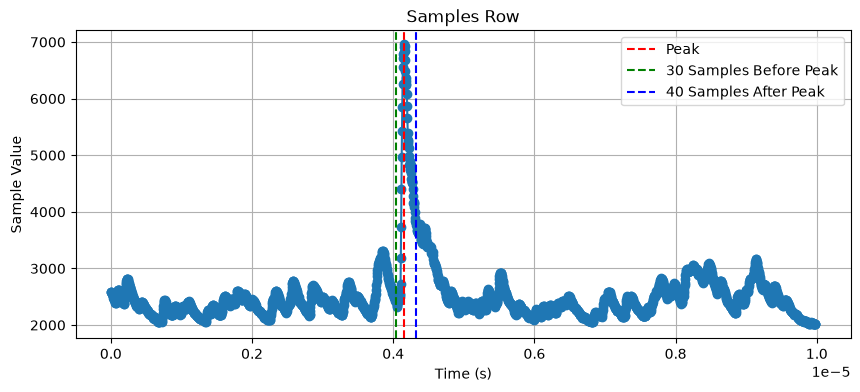

In [8]:
# Grab only the 'SAMPLES' columns AND only the first 2 rows up front
df_samples_subset = df.filter(like='SAMPLES').head(1)

#convert to an np array for plotting
samples_array = df_samples_subset.iloc[0].values


len_samples = len(samples_array)

frequency = 250000000  # Frequency in Hz
period = 1 / frequency  # Period in seconds


time = np.arange(len_samples) * period  # Create a time array for plotting


df_samples = pd.DataFrame({
    'time_s': time,
    'signal_v': samples_array
})

plt.figure(figsize=(10, 4))
plt.plot(time, samples_array, marker='o')
plt.title(f'Samples Row')
plt.xlabel('Time (s)')
plt.ylabel('Sample Value')
plt.grid()
#vertical lines at the peak and 10 samples before and 40 samples after
peak_idx = np.argmax(samples_array)
print(f"Peak index: {peak_idx}, Peak value: {samples_array[peak_idx]}")
plt.axvline(x=time[peak_idx], color='r', linestyle='--', label='Peak')
plt.axvline(x=time[max(0, peak_idx-30)], color='g', linestyle='--', label='30 Samples Before Peak')
plt.axvline(x=time[min(len_samples-1, peak_idx+40)], color='b', linestyle='--', label='40 Samples After Peak')
plt.legend()
